## Solución T01 - Variables Discretas
### Temas: Reglas de Asociación y Árboles de Clasificación para variables categóricas.
### Autor: Johana Cómbita Niño

En la presente tarea consideraremos el dataset `Mushroom`, incluido tanto en la La librería [arulesViz](https://cran.r-project.org/web/packages/arulesViz/arulesViz.pdf) como en las diferentes plataformas descritas en el marco de la asignatura y en el GitHub dedicado a este Máster ([Mushroom](https://github.com/SantanderMetGroup/Master-Data-Science/blob/master/Data_mining/datasets/mushrooms.csv.)), para aplicar las diferentes técnicas vistas en el curso para variables categóricas: Reglas de Asociación y Árboles de Clasificación.

Para el desarrollo de la tarea se permitirá el uso de todo el material incluido en el Moodle de las asignatura así como el desarrollado por el/la alumn@ durante la realización de las prácticas.

La entrega consisitirá de un notebook de Jupyter ó un R-MarkDown, junto con el archivo html que éste genera. Ambos ficheros se entregarán a través del Moodle de la asignatura en la tarea correspondiente.

### Punto 1 (3 puntos):

Considerar uno de los algoritmos de asociación vistos en clase y obtener las reglas representativas del dataset fijando los parámetros de aprendizaje (soporte, confianza, etc...). Analizar los resultados en términos generales:
* ¿Cuantas reglas se han generado?
* ¿Existe alguna regla redundante?, ¿Cuántas?
* ¿Existe alguna regla que incluya la variable objetivo: `Class=edible` ó `Class=poisonous`?, ¿Cuantas?
* De cara a ser utilizada como modelo predictivo es adecuado que la variable objetivo se encuentre en el consecuente de la regla de asociación, ¿se da esta propiedad en alguna regla?
* Considerar los subconjuntos de reglas con ambas clases como consecuente e ilustrar las variables implicadas en cada caso. Considerar alguno de los grafos vistos para apoyar las conclusiones obtenidas.

NOTA: Usar soportes superiores a 0.1 para evitar problemas de memoria.as de memoria.

Primero se instalan y cargan paquetes a utilizar, se cargan los datos y se acondiciona el dataset.

In [287]:
install.packages("arules")

Warning message in install.packages("arules"):
“installation of package ‘arules’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [292]:
library("arules")
data("Mushroom")
library("arulesViz")

In [305]:
#Explorando los datos
?mushroom
#str(Mushroom)
summary(Mushroom)
#itemLabels(Mushroom) 
#inspect(head(Mushroom))

transactions as itemMatrix in sparse format with
 8124 rows (elements/itemsets/transactions) and
 114 columns (items) and a density of 0.1925851 

most frequent items:
 VeilType=partial   VeilColor=white GillAttached=free    RingNumber=one 
             8124              7924              7914              7488 
  GillSpace=close           (Other) 
             6812            140098 

element (itemset/transaction) length distribution:
sizes
  21   22   23 
2312 3868 1944 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  21.00   21.00   22.00   21.95   22.00   23.00 

includes extended item information - examples:
           labels variables    levels
1    Class=edible     Class    edible
2 Class=poisonous     Class poisonous
3   CapShape=bell  CapShape      bell

Mushroom {arules},R Documentation


##### Características principales: 
- 	Muestras de 23 especies de hongos de las familias Agaricus y Lepiot.
-	Observaciones 8124 (muestras): donde 4208 (51%) son comestibles (e) y 3916 (48,2%) son venenosos (p). traduce a 114 artículo

-	22 variables (características ) + atributo de clase (variable obj: comestible o). no

Adicionalmente, en summary podemos observar que existe un item que se presenta en todas las observaciones, el cual es VeilType=partial. Esto quiere decir que VeilType presenta un único nivel para todas las observaciones, y esto no aporta información a la construcción de reglas. Tambien, observamos que el tamaño máximo de itemset es 23, presentandose 1944 veces. 

In [306]:
# Filtrando datos sin columna (`VeilType=partial`)
Mushroom_filt = Mushroom[, !colnames(Mushroom) %in% c("VeilType=partial")]

In [307]:
#Inspección 
itemLabels(Mushroom_filt)
#str(Mushroom_filt)
summary(Mushroom_filt)

[1] "Class=edible"             "Class=poisonous"         
  [3] "CapShape=bell"            "CapShape=conical"        
  [5] "CapShape=flat"            "CapShape=knobbed"        
  [7] "CapShape=sunken"          "CapShape=convex"         
  [9] "CapSurf=fibrous"          "CapSurf=grooves"         
 [11] "CapSurf=smooth"           "CapSurf=scaly"           
 [13] "CapColor=buff"            "CapColor=cinnamon"       
 [15] "CapColor=red"             "CapColor=gray"           
 [17] "CapColor=brown"           "CapColor=pink"           
 [19] "CapColor=green"           "CapColor=purple"         
 [21] "CapColor=white"           "CapColor=yellow"         
 [23] "Bruises=no"               "Bruises=bruises"         
 [25] "Odor=almond"              "Odor=creosote"           
 [27] "Odor=foul"                "Odor=anise"              
 [29] "Odor=musty"               "Odor=none"               
 [31] "Odor=pungent"             "Odor=spicy"              
 [33] "Odor=fishy"               "GillAttached=attached"   
 [35] "GillAttached=free"        "GillSpace=close"         
 [37] "GillSpace=crowded"        "GillSize=broad"          
 [39] "GillSize=narrow"          "GillColor=buff"          
 [41] "GillColor=red"            "GillColor=gray"          
 [43] "GillColor=chocolate"      "GillColor=black"         
 [45] "GillColor=brown"          "GillColor=orange"        
 [47] "GillColor=pink"           "GillColor=green"         
 [49] "GillColor=purple"         "GillColor=white"         
 [51] "GillColor=yellow"         "StalkShape=enlarging"    
 [53] "StalkShape=tapering"      "StalkRoot=bulbous"       
 [55] "StalkRoot=club"           "StalkRoot=equal"         
 [57] "StalkRoot=rooted"         "SurfaceAboveRing=fibrous"
 [59] "SurfaceAboveRing=silky"   "SurfaceAboveRing=smooth" 
 [61] "SurfaceAboveRing=scaly"   "SurfaceBelowRing=fibrous"
 [63] "SurfaceBelowRing=silky"   "SurfaceBelowRing=smooth" 
 [65] "SurfaceBelowRing=scaly"   "ColorAboveRing=buff"     
 [67] "ColorAboveRing=cinnamon"  "ColorAboveRing=red"      
 [69] "ColorAboveRing=gray"      "ColorAboveRing=brown"    
 [71] "ColorAboveRing=orange"    "ColorAboveRing=pink"     
 [73] "ColorAboveRing=white"     "ColorAboveRing=yellow"   
 [75] "ColorBelowRing=buff"      "ColorBelowRing=cinnamon" 
 [77] "ColorBelowRing=red"       "ColorBelowRing=gray"     
 [79] "ColorBelowRing=brown"     "ColorBelowRing=orange"   
 [81] "ColorBelowRing=pink"      "ColorBelowRing=white"    
 [83] "ColorBelowRing=yellow"    "VeilColor=brown"         
 [85] "VeilColor=orange"         "VeilColor=white"         
 [87] "VeilColor=yellow"         "RingNumber=none"         
 [89] "RingNumber=one"           "RingNumber=two"          
 [91] "RingType=evanescent"      "RingType=flaring"        
 [93] "RingType=large"           "RingType=none"           
 [95] "RingType=pendant"         "Spore=buff"              
 [97] "Spore=chocolate"          "Spore=black"             
 [99] "Spore=brown"              "Spore=orange"            
[101] "Spore=green"              "Spore=purple"            
[103] "Spore=white"              "Spore=yellow"            
[105] "Population=brown"         "Population=yellow"       
[107] "Habitat=woods"            "Habitat=grasses"         
[109] "Habitat=leaves"           "Habitat=meadows"         
[111] "Habitat=paths"            "Habitat=urban"           
[113] "Habitat=waste"

transactions as itemMatrix in sparse format with
 8124 rows (elements/itemsets/transactions) and
 113 columns (items) and a density of 0.1854398 

most frequent items:
  VeilColor=white GillAttached=free    RingNumber=one   GillSpace=close 
             7924              7914              7488              6812 
   GillSize=broad           (Other) 
             5612            134486 

element (itemset/transaction) length distribution:
sizes
  20   21   22 
2312 3868 1944 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  20.00   20.00   21.00   20.95   21.00   22.00 

includes extended item information - examples:
           labels variables    levels
1    Class=edible     Class    edible
2 Class=poisonous     Class poisonous
3   CapShape=bell  CapShape      bell

Ahora observamos que el tamaño máximo de itemset es 22, presentandose 1944 veces, pero el mas frecuente es 21 con 3868. Vamos a ampliar un poco mas los items mas frecuentes, porque en summary solo se observan los 5 primeros.

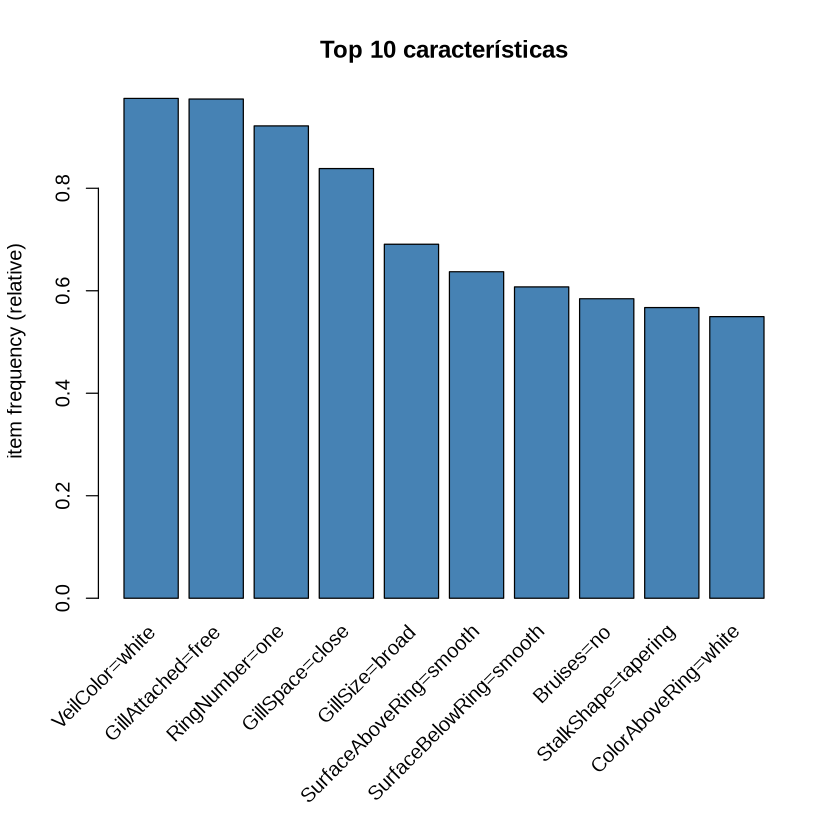

In [308]:
itemFrequencyPlot(Mushroom_filt, topN = 10, col = "steelblue", main = "Top 10 características")

Se configuran los parametros para empezar a explorar las reglas de asociación. Se establece un soporte mínimo de 0.2 (20%) para incluir ítems o combinaciones que ocurran al menos en el 20% de las transacciones, obteniendo un panorama amplio de reglas; un maxlen de 21 debido a que observamos que el tamaño máximo frecuente de itemsets que podía haber era de 21 con un número significativo de ocurrencias; y finalmente una confianza de 0.8 que nos indica la probabilidad de que RHS ocurra dado que el LHS ocurra, de esta forma vamos a garantizar que aparezcan relaciones consistente y confiables. 

In [309]:
sup = 0.2
max_item = 21
conf = 0.8

items_Eclat = eclat(Mushroom_filt, parameter = list(support = sup,
                                                maxlen = max_item, 
                                                tidLists = TRUE))

Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
     TRUE     0.2      1     21 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 1624 

create itemset ... 
set transactions ...[113 item(s), 8124 transaction(s)] done [0.02s].
sorting and recoding items ... [40 item(s)] done [0.00s].
creating bit matrix ... [40 row(s), 8124 column(s)] done [0.00s].
writing  ... [20457 set(s)] done [0.96s].
Creating S4 object  ... done [1.25s].


En los resultados obtenidos se puede observar una cantidad de 20457 conjuntos frecuentes de ítems (itemsets) de tamaño entre 1 y 21, los cuales cumplen con el criterio de soporte mínimo del 20% (es decir, aparecen en al menos 1624 transacciones).
Ahora bien, como la cantidad de itemsets es grande, podemos filtrar los itemsets que contengan las caracteristicas mas frecuentes. 

In [310]:
items_filt = subset(items_Eclat, subset = items %in% c("VeilColor=white","GillAttached=free", "RingNumber=one", "GillSpace=close", "GillSize=broad", 
                "SurfaceAboveRing=smooth", "SurfaceBelowRing=smooth", "Bruises=no", "StalkShape=tapering", "ColorAboveRing=white"))

summary(items_filt)

set of 20311 itemsets

most frequent items:
    VeilColor=white   GillAttached=free      RingNumber=one     GillSpace=close 
              10217               10216               10057                9834 
StalkShape=tapering             (Other) 
               9376               84276 

element (itemset/transaction) length distribution:sizes
   1    2    3    4    5    6    7    8    9   10   11   12   13   14 
  10  248  943 1951 2961 3681 3806 3171 2057 1012  365   91   14    1 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   5.000   7.000   6.596   8.000  14.000 

summary of quality measures:
    support           count     
 Min.   :0.2001   Min.   :1626  
 1st Qu.:0.2127   1st Qu.:1728  
 Median :0.2127   Median :1728  
 Mean   :0.2300   Mean   :1868  
 3rd Qu.:0.2245   3rd Qu.:1824  
 Max.   :0.9754   Max.   :7924  

includes transaction ID lists: TRUE 

mining info:
          data ntransactions support
 Mushroom_filt          8124     0.2
                           

Con este filtro nos damos cuenta que no hay una diferencia significativa, pasando de 20457 conjuntos frecuentes de ítems a 20311. Esto quiere decir que con los parámetros aplicados la mayoría de los itemset presenta alguna de las caracteristicas identificadas en el top 10 de frecuencia. Ahora, revisemos la cantidad de reglas a generar:

In [311]:
# 1. ¿Cuantas reglas se han generado?
reglas = ruleInduction(items_filt, Mushroom_filt, confidence = conf, 
                                                control = list(method = "ptree", reduce = TRUE))
T_reglas = length(reglas)

cat("El total de reglas generadas bajo unos parametros mínimos, 
con soporte ", sup,", confianza ", conf," y un máximo de ", max_item," itemsets, fueron: ", T_reglas, "\n")

El total de reglas generadas bajo unos parametros mínimos, 
con soporte  0.2 , confianza  0.8  y un máximo de  21  itemsets, fueron:  123296 


La cantidad de reglas generadas es bastante alta, pero es importante mencionar que en estas reglas puede haber redundancia. Vamos a identificar cuales son y filtrar. 

In [312]:
# 2. ¿Existe alguna regla redundante?, ¿Cuántas?
reglas_redundantes = which(is.redundant(reglas))
r_redundantes = reglas[reglas_redundantes]
T_redundantes = length(r_redundantes)

cat("El total de reglas redundantes es: ", T_redundantes, "\n")

El total de reglas redundantes es:  120839 


In [313]:
# Filtrar reglas sin redundancia
reglas_filt = reglas[!is.redundant(reglas)]

cat("El total de reglas sin redundancia es: ", length(reglas_filt), "\n")

El total de reglas sin redundancia es:  2457 


Con este filtro tenemos las reglas más importantes, las cuales no presentan redundancia, tienen una confianza de por lo menos 80% y un soporte de al menos 20%. Adicionalmente, podemos decir que estas reglas presentan algunos de los items (caracteristicas de hongos) que se identificaron como frecuentes en puntos anteriores. 

Ahora bien, miremos si alguna de las reglas incluye la variable objetivo `Class=edible` ó `Class=poisonous`

In [315]:
# 3. ¿Existe alguna regla que incluya la variable objetivo: `Class=edible` ó `Class=poisonous`?, ¿Cuantas?

subset_var_obj = subset(reglas_filt, subset = rhs %in% c("Class=edible", "Class=poisonous") | lhs %in% c("Class=edible", "Class=poisonous"))
reglas_edible = subset(reglas_filt, subset = rhs %in% c("Class=edible") | lhs %in% c("Class=edible"))
reglas_poisonous = subset(reglas_filt, subset = rhs %in% c("Class=poisonous") | lhs %in% c("Class=poisonous"))

cat(" En total las reglas que incluyen la variable objetivo son ", length(subset_var_obj), ", donde",
    length(reglas_edible), " son Class=edible y ", length(reglas_poisonous), " son Class=poisonous.")

 En total las reglas que incluyen la variable objetivo son  880 , donde 683  son Class=edible y  197  son Class=poisonous.

Es importante que la variable objetivo se encuentre en el consecuente de la regla de asociación, por lo cual vamos a filtrar este aspecto para saber cuantas reglas lo cumplen. 

In [316]:
# 4. De cara a ser utilizada como modelo predictivo es adecuado que la variable objetivo se encuentre en el consecuente de la regla de asociación, ¿se da esta propiedad en alguna regla?
subset_rhs = subset(subset_var_obj, subset = rhs %in% c("Class=edible", "Class=poisonous"))
subset_rhs_e = subset(subset_var_obj, subset = rhs %in% c("Class=edible"))
subset_rhs_p = subset(subset_var_obj, subset = rhs %in% c("Class=poisonous"))

cat("En total las reglas que incluyen la variable objetivo en el consecuente son ", length(subset_rhs), ", donde",
    length(subset_rhs_e), " son Class=edible y ", length(subset_rhs_p), " son Class=poisonous.")


En total las reglas que incluyen la variable objetivo en el consecuente son  219 , donde 157  son Class=edible y  62  son Class=poisonous.

Para analizar un poco mas los resultados obtenidos y las reglas generadas, podemos ordenar las reglas con respecto a otro parmetro como lift, que representa la correlación positiva o negativa del antecedente con consecuente, la cual se interpreta que valores mayores a 1 presentan una mayor probabilidad de que cuando ocurra LHS ocurre RHS.

In [317]:
#10 primeras reglas que muestran una correlación positiva alta para Class=edible
inspect(head(sort(subset_rhs_e, by ="lift"),10))

     lhs                           rhs              support confidence     lift itemset
[1]  {GillSize=broad,                                                                  
      Spore=brown}              => {Class=edible} 0.2028557          1 1.930608    1118
[2]  {Bruises=bruises,                                                                 
      VeilColor=white,                                                                 
      Habitat=woods}            => {Class=edible} 0.2245199          1 1.930608    6371
[3]  {Bruises=bruises,                                                                 
      GillAttached=free,                                                               
      Habitat=woods}            => {Class=edible} 0.2245199          1 1.930608    6372
[4]  {Bruises=bruises,                                                                 
      RingNumber=one,                                                                  
      Habitat=woods}            

In [318]:
#10 primeras reglas que muestran una correlación positiva alta para Class=poisonous
inspect(head(sort(subset_rhs_p, by ="lift"),10))

     lhs                      rhs                 support confidence     lift itemset
[1]  {GillColor=buff,                                                                
      VeilColor=white}     => {Class=poisonous} 0.2127031          1 2.074566     940
[2]  {GillAttached=free,                                                             
      GillColor=buff}      => {Class=poisonous} 0.2127031          1 2.074566     941
[3]  {GillColor=buff,                                                                
      RingNumber=one}      => {Class=poisonous} 0.2127031          1 2.074566     942
[4]  {GillSpace=close,                                                               
      GillColor=buff}      => {Class=poisonous} 0.2127031          1 2.074566     943
[5]  {Bruises=no,                                                                    
      GillColor=buff}      => {Class=poisonous} 0.2127031          1 2.074566     944
[6]  {GillColor=buff,                                 

En estas primeras reglas podemos observar que hay una confianza del 100%, lo cual es muy bueno porque garantiza que dado unas caracteristicas de los hongos en el antecedente, se obtiene una clase en el consecuente. 

Ahora apliquemos otra consulta para inspeccionar las reglas con soportes mas altos para el subset de la variable objetivo (Class=poisonous y Class=edible) y revisar que resultados obtenemos de los parámetros.

In [319]:
#10 primeras reglas que muestran los mayores soportes para Class=poisonous y Class=edible
inspect(head(sort(subset_rhs, by ="support"),10))

     lhs                          rhs                 support confidence     lift itemset
[1]  {GillSize=broad,                                                                    
      SurfaceAboveRing=smooth} => {Class=edible}    0.4155588  0.9398664 1.814514   19608
[2]  {Odor=none,                                                                         
      VeilColor=white}         => {Class=edible}    0.3958641  0.9663462 1.865636   16983
[3]  {Odor=none,                                                                         
      GillAttached=free}       => {Class=edible}    0.3958641  0.9640288 1.861162   16984
[4]  {Odor=none,                                                                         
      GillSize=broad}          => {Class=edible}    0.3958641  0.9781022 1.888332   16987
[5]  {Bruises=no,                                                                        
      GillSpace=close,                                                                   
      Veil

En estos resultados observamos que las 10 primeras reglas tienen un soporte de alrededor del 40%, es decir una ocurrencia en las transacciones mucho mas alta de la establecida en la configuzarción base. Tambien observamos una confianza alrededor del 95%, lo cual representa que hay una probabilidad alta de que cuando ocurran los elementos del antecedente, se pueda establecer un consecuente clase poisonous o edible. Finalmente, valores de lift mayores que uno que soportan la correlación positiva de estas mismas reglas. 

Ahora hagamos unas gráficas que nos permitan hacer un análisis mas profundo de los resultados. 

Warning message in plot.rules(subset_rhs, method = NULL, measure = "support", shading = "lift", :
“The parameter interactive is deprecated. Use engine='interactive' instead.”
To reduce overplotting, jitter is added! Use jitter = 0 to prevent jitter.



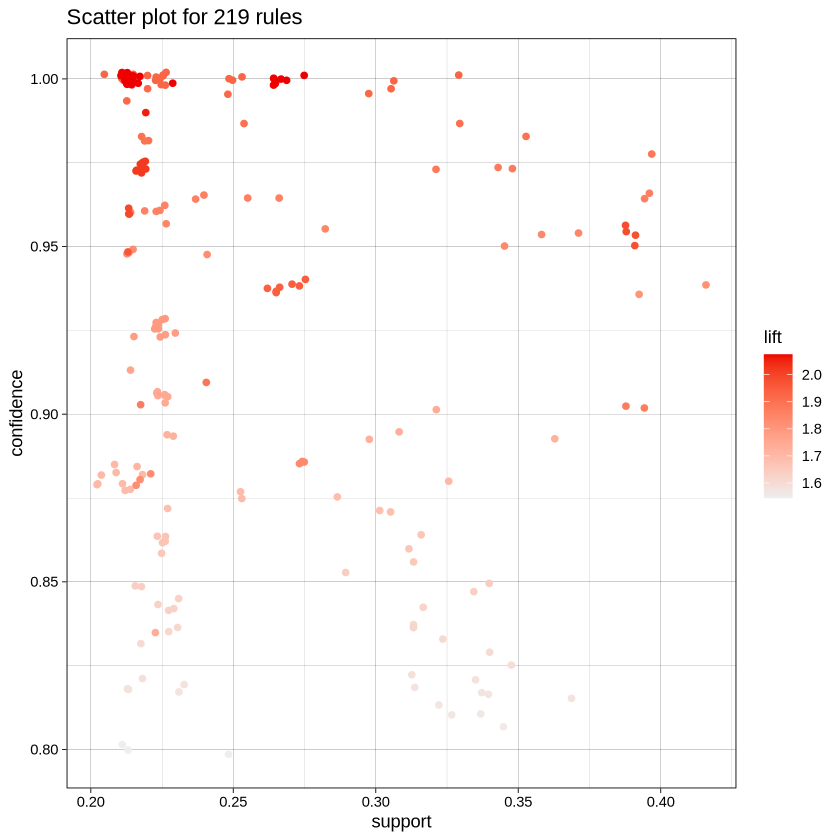

In [320]:
# 5. Considerar los subconjuntos de reglas con ambas clases como consecuente e ilustrar las variables implicadas en cada caso. Considerar alguno de los grafos vistos para apoyar las conclusiones obtenidas.
#install.packages("htmlwidgets")
#library("htmlwidgets")
# Grafico teniendo en cuenta las reglas que incluyen la variable objetivo en el consecuente ({Class=poisonous} y {Class=edible} )
plot(subset_rhs, method = NULL, measure = "support", shading = "lift", interactive = FALSE, data = NULL, control = NULL)

En esta gráfica podemos observar el comportamiento de las 219 reglas que contienen como consecuente a la variable objetivo Class=poisonous y Class=edible. Como se concluyo con los análisis de filtrado hechos en el punto anterior, se puede observar que hay una gran cantidad de reglas con un lift mayor a 1. Incluso se puede observar que la escala de lift es de 1.6 a 2, por lo cual las 219 presentan una correlación positiva entre LHS y RHS, es decir que cuando estan esas caracteristicas de los hongos es posible definir la variable objetivo clase. Adicionalmente, se observan confianzas desde el 80% hasta 100%, donde una gran cantidad con lift alto estan entre el 90% y 100%. ESto quiere decir de que dados los items antecedentes es muy probable que se den los consecuente. Finalmente, se observan soportes alrededor del 20% al 40%, lo cual respalda las transacciones que incluyen la variable objetivo en el RHS. 

Finalmente, vamos a hacer un ultimo análisis para identificar cuales podrían ser los items más importantes relacionados con la variable objetivo y que en mayor medida se encuentran en las reglas.

Warning message:
“Too many rules supplied. Only plotting the best 100 using ‘lift’ (change control parameter max if needed).”


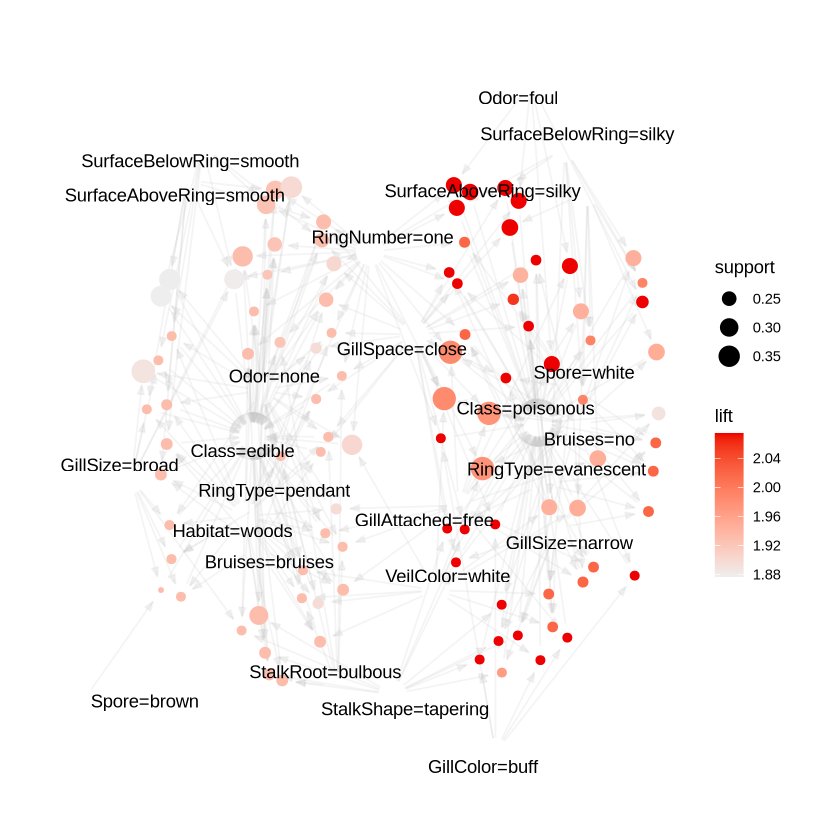

In [324]:
# Grafico de reglas para Class=edible y Class=poisonous 
plot(subset_rhs, method = "graph")

En estas gráficas podemos ver 219 reglas, de las cuales 157 son Class=edible y  62  son Class=poisonous como consecuente. En el grafico se observa la relación de los items que conforman las reglas más importantes. Del lado izquierdo estan las items que más se asociadan con la formación de reglas relacionadas con Class=edible, destacando a Odor=none, habitat=woods, GillSize=broad, gillsize=broad, bruises=bruises, entre otros. Los items que conforman las reglas mas importantes que se asocian con Class=poisonous como consecuente, destacan características de los hongos como spore=white, VeilColor=white, bruises=no, RingType=evanescent, entre otros. Vemos que algunos de estos items coinciden entre los dos grupos de la variable objetivo, como ringNumber=one, Gillspace=close, gillattached=free, veilColor=white y stalkshape=tapering.

### Punto 2 (4 puntos):
En este apartado aplicaremos árboles de clasificación para obtener un modelo que permita clasificar una nueva entrada. Para ello, vamos a utilizar el paquete CaReT. Este paquete (y los demás que hemos visto para trabajar con árboles en R) no aceptan objetos del tipo transactions como los del apartado anterior. Por tanto, hemos preparado un fichero csv con el dataset Mushrooms; puedes descargarlo desde esta aquí: https://github.com/SantanderMetGroup/Master-Data-Science/tree/master/Data_mining/datasets. Puedes leer este dataset con la función read.csv.
Ahora ya tenemos un data.frame con el que podemos empezar a trabajar. En primer lugar tendremos que eliminar la columna 17 (veil.type), ya que contiene un único nivel y daría errores en CaReT(esta columna podría eliminarse también en el caso de las reglas de asociación ya que no aporta información al dataset).
Nuestro objetivo será encontrar la configuración (profundidad) óptima del árbol. Para ello, dividiremos el dataset en dos subconjuntos indpendedientes de train y test (75% y 25% del total, respectivamente). Sobre el dataset de train, aplicaremos una cross-validación con 3 folds y la repetiremos 50 veces (recuerda que los árboles son sensibles a la partición train/test que se considere
* ¿Cuál es la configuración óptima del árbol? ¿Hay alguna diferencia entre el árbol *completo* y el óptimo? ¿Por qué crees que ocurre esto?
* ¿Cuáles son las dos variables que mayor peso tienen a la hora de clasificar? Entrena un nuevo árbol considerando como predictores únicamente esas dos variables. ¿Qué resultados obtienes? 
* Entrena un nuevo árbol considerando como predictores cualesquiera otras dos variables que no sean las utilizadas en la pregunta anterior. ¿Cuál es el error de test de este árbol? árbol?

Primero se instalan y cargan paquetes a utilizar, se cargan los datos y se acondiciona el dataset.

In [331]:
#install.packages("caret")
#install.packages("tree")
#install.packages("rpart.plot")
library(caret)
library(tree)
library(rpart)
library(rpart.plot)

In [332]:
#Cargando datos
dataset_mushroom = read.csv('mushrooms.csv',sep = ",", header = TRUE)

#Explorando los datos
#head(dataset_mushroom)
str(dataset_mushroom)

'data.frame':	8124 obs. of  23 variables:
 $ class                   : chr  "p" "e" "e" "p" ...
 $ cap.shape               : chr  "x" "x" "b" "x" ...
 $ cap.surface             : chr  "s" "s" "s" "y" ...
 $ cap.color               : chr  "n" "y" "w" "w" ...
 $ bruises                 : chr  "t" "t" "t" "t" ...
 $ odor                    : chr  "p" "a" "l" "p" ...
 $ gill.attachment         : chr  "f" "f" "f" "f" ...
 $ gill.spacing            : chr  "c" "c" "c" "c" ...
 $ gill.size               : chr  "n" "b" "b" "n" ...
 $ gill.color              : chr  "k" "k" "n" "n" ...
 $ stalk.shape             : chr  "e" "e" "e" "e" ...
 $ stalk.root              : chr  "e" "c" "c" "e" ...
 $ stalk.surface.above.ring: chr  "s" "s" "s" "s" ...
 $ stalk.surface.below.ring: chr  "s" "s" "s" "s" ...
 $ stalk.color.above.ring  : chr  "w" "w" "w" "w" ...
 $ stalk.color.below.ring  : chr  "w" "w" "w" "w" ...
 $ veil.type               : chr  "p" "p" "p" "p" ...
 $ veil.color              : chr  "w" "w

En primer lugar tendremos que eliminar la columna 17 (veil.type), ya que contiene un único nivel y daría errores en CaReT. Además, se debe cambiar las variables a factor, debido a que se va a entrenar un modelo de arbol de clasificación de variables discretas y todas las variables son categoricas. 

In [333]:
#Eliminado columna veil-type (17)
dataset_mush_clean = dataset_mushroom[,-17]

In [334]:
#Cambiando las variables a factor (predictor y predictando)
for(i in 1:ncol(dataset_mush_clean)){
  dataset_mush_clean[,i] = as.factor(dataset_mush_clean[,i])
}

In [335]:
#Revisando cambios
str(dataset_mush_clean)

'data.frame':	8124 obs. of  22 variables:
 $ class                   : Factor w/ 2 levels "e","p": 2 1 1 2 1 1 1 1 2 1 ...
 $ cap.shape               : Factor w/ 6 levels "b","c","f","k",..: 6 6 1 6 6 6 1 1 6 1 ...
 $ cap.surface             : Factor w/ 4 levels "f","g","s","y": 3 3 3 4 3 4 3 4 4 3 ...
 $ cap.color               : Factor w/ 10 levels "b","c","e","g",..: 5 10 9 9 4 10 9 9 9 10 ...
 $ bruises                 : Factor w/ 2 levels "f","t": 2 2 2 2 1 2 2 2 2 2 ...
 $ odor                    : Factor w/ 9 levels "a","c","f","l",..: 7 1 4 7 6 1 1 4 7 1 ...
 $ gill.attachment         : Factor w/ 2 levels "a","f": 2 2 2 2 2 2 2 2 2 2 ...
 $ gill.spacing            : Factor w/ 2 levels "c","w": 1 1 1 1 2 1 1 1 1 1 ...
 $ gill.size               : Factor w/ 2 levels "b","n": 2 1 1 2 1 1 1 1 2 1 ...
 $ gill.color              : Factor w/ 12 levels "b","e","g","h",..: 5 5 6 6 5 6 3 6 8 3 ...
 $ stalk.shape             : Factor w/ 2 levels "e","t": 1 1 1 1 2 1 1 1 1 1 ...
 $ stalk.r

Se crea una función para calcular la medida de evaluación accuracy, la cual utilizaremos más adelante. 

In [336]:
#Funcion de accuracy como metrica de validación 
acc.class = function(x, y) {
  stopifnot(length(x) == length(y))
  return(sum(diag(table(x, y))) / length(x))
}

Recordemos que esta base de datos almacena especies de hongos de las familias Agaricus y Lepiot, con 8124 observaciones, donde 4208 (51%) son comestibles (e) y 3916 (48,2%) son venenosos (p) (Class es la variable objetivo). Con la columna eliminada, tenemos 21 variables (características de hongos) + atributo de clase (variable obj: comestible o no).

Para entrenar el modelo consideremos una partición de los datos en dos subconjuntos independientes, train (75%) y test (25%), escogido aleatoreamente. Es importante mencionar que el dataset se encuentra balanceado entre obervaciones de hongos comestibles y venenoso (51% son comestibles y 48.2% son venenosos), por lo cual no es necesario estratificar la división. 

In [337]:
#division train y test
n = nrow(dataset_mush_clean)
set.seed(412)
ind_train = sample(1:n, round(0.75*n))
ind_test = setdiff(1:n, ind_train)
dataset.train_msh = dataset_mush_clean[ind_train,]
dataset.test_msh = dataset_mush_clean[ind_test,]

nrow(dataset.train_msh)
nrow(dataset.test_msh)

[1] 6093

[1] 2031

Como siguiente paso se construye el arbol completo para conocer los nodos terminales que permite llegar a un resultado con error cero, y cuales son las variables más importantes. Para esto es importante forzar el modelo con los hyper-parametros que ayudan a construir el modelo, permitiendolo dejarlo crecer. El primer elemento a configurar es el parámetro de complejidad cp, el cual controla la poda del arbol determinando el nivel mínimo de mejora en la reducción del error relativo o la impureza necesaria para que un nodo se divida. Valores pequeños de cp permiten mas divisiones, por lo cual el valor cero permite llegar a una pureza del 100%. El segundo hyper-parámetro es minsplit, el cual representa el número mínimo de observaciones necesarias para una división de un nodo, por lo cual el valor mas pequeño es de 2. El tercer hyper-parámetro es minbucket representa el número mínimo de observaciones en nodo terminal, el cual como mínimo se establece 1. Este parámetro se encuentra relacionado con minsplit, donde este representa las observaciones mínimas del nodo padre y minbucket las observaciones del nodo hijo. Finalmente, se configura el hyper-parámetro maxdepth con un valor alto (20), el cual representa la profundidad máxima del árbol o niveles. 

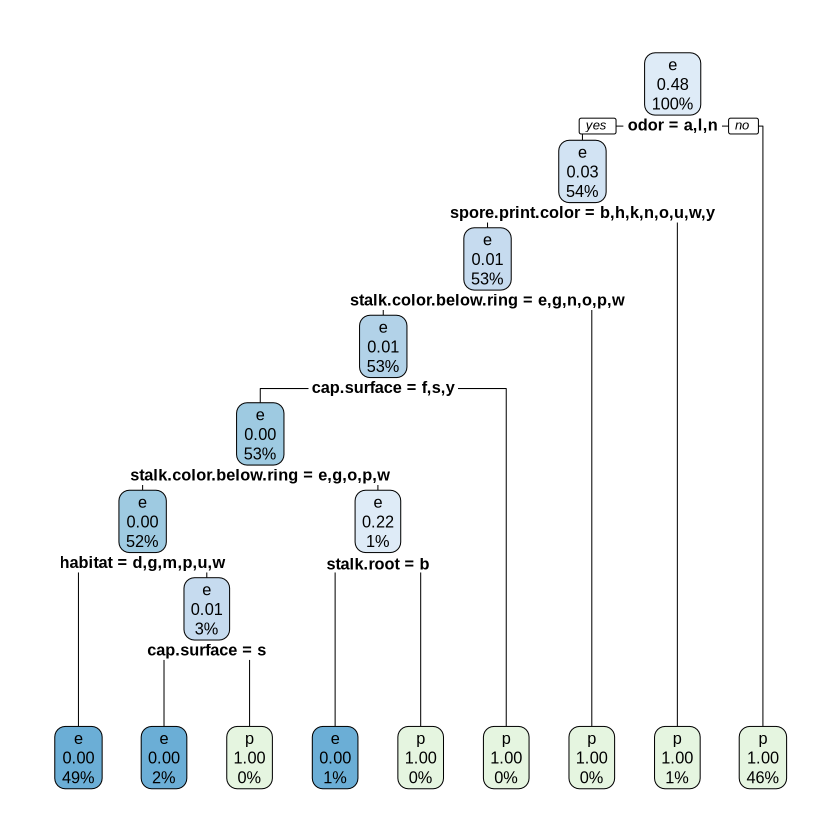

In [338]:
#Pregunta 1: ¿Cuál es la configuración óptima del árbol? ¿Hay alguna diferencia entre el árbol completo y el óptimo? ¿Por qué crees que ocurre esto?
#Arbol completo
tree_completo <- rpart(class ~ ., data = dataset.train_msh, method = "class", 
                        control = rpart.control(cp = 0,     # Complejidad baja para permitir la mayor cantidad de divisiones
                                                minsplit = 2,     # Número mínimo de observaciones necesarias para dividir un nodo
                                                minbucket = 1,    # Número mínimo de observaciones en un nodo terminal (hoja)
                                                maxdepth = 20     # Profundidad máxima del árbol (niveles)
                                                 ))

#Representación del arbol
rpart.plot(tree_completo) 

In [339]:
# Error de clasificación e información de variables usadas en el arbol
printcp(tree_completo) 


Classification tree:
rpart(formula = class ~ ., data = dataset.train_msh, method = "class", 
    control = rpart.control(cp = 0, minsplit = 2, minbucket = 1, 
        maxdepth = 20))

Variables actually used in tree construction:
[1] cap.surface            habitat                odor                  
[4] spore.print.color      stalk.color.below.ring stalk.root            

Root node error: 2905/6093 = 0.47678

n= 6093 

          CP nsplit  rel error    xerror       xstd
1 0.97005164      0 1.00000000 1.0000000 0.01342056
2 0.01721170      1 0.02994836 0.0299484 0.00318780
3 0.00654045      2 0.01273666 0.0127367 0.00208753
4 0.00195066      3 0.00619621 0.0061962 0.00145830
5 0.00017212      6 0.00034423 0.0010327 0.00059608
6 0.00000000      8 0.00000000 0.0010327 0.00059608


In [340]:
# Información de variables importantes, estructura del arbol y precisión del modelo
summary(tree_completo)

Call:
rpart(formula = class ~ ., data = dataset.train_msh, method = "class", 
    control = rpart.control(cp = 0, minsplit = 2, minbucket = 1, 
        maxdepth = 20))
  n= 6093 

           CP nsplit    rel error      xerror         xstd
1 0.970051635      0 1.0000000000 1.000000000 0.0134205557
2 0.017211704      1 0.0299483649 0.029948365 0.0031877963
3 0.006540448      2 0.0127366609 0.012736661 0.0020875268
4 0.001950660      3 0.0061962134 0.006196213 0.0014583027
5 0.000172117      6 0.0003442341 0.001032702 0.0005960841
6 0.000000000      8 0.0000000000 0.001032702 0.0005960841

Variable importance
                    odor        spore.print.color               gill.color 
                      25                       19                       15 
stalk.surface.below.ring stalk.surface.above.ring                ring.type 
                      13                       13                       13 

Node number 1: 6093 observations,    complexity param=0.9700516
  predicted class

Este modelo tiene 9 nodos terminales, y utiliza 6 variables relevantes para dividir los datos, que son: odor, spore.print.color, stalk.color.below.ring, cap.surface, habitat, y stalk.root (como se observa en el esquema del arbol y en printcp), donde dos de ellas aparecen dos veces en alguno de los niveles del arbol (stalk.color.below.ring y cap.surface). Por su parte, podemos ver que en summary se destacan otras variables importantes como gill.color, stalk.surface.below.ring, stalk.surface.above.ring y ring.type, lo cual se debe al algoritmo, que selecciona las variables que reducen la impureza en cada nivel. De esto se destaca que las variables odor y spore.print.color son importantes y reducen la impureza, por lo cual hasta ahora se podría decir que son las variables principales del modelo. 

Adicionalmente, se observa que todos los nodos terminales son puros, es decir, todas las instancias de ese nodo pertenecen a la misma clase. Sin embargo, este comportamiento puede estar asociado al sobreajuste, ya que el modelo podría haber aprendido patrones específicos del conjunto de entrenamiento y no generalizar bien a nuevos datos. Además, es importante denotar que el nivel de profundidad del arbol es de 7 a pesar de que se estableció un valor de maxdepth de 20. Esto quiere decir que el modelo alcanza un error mínimo teniendo en cuenta unas cuantas variables (cp y error relativo 0 en summary).

Ahora busquemos la profundidad óptima del arbol aplicando una cross-validación con 3 folds y repitiendo 50 veces para encontrar el óptimo. 

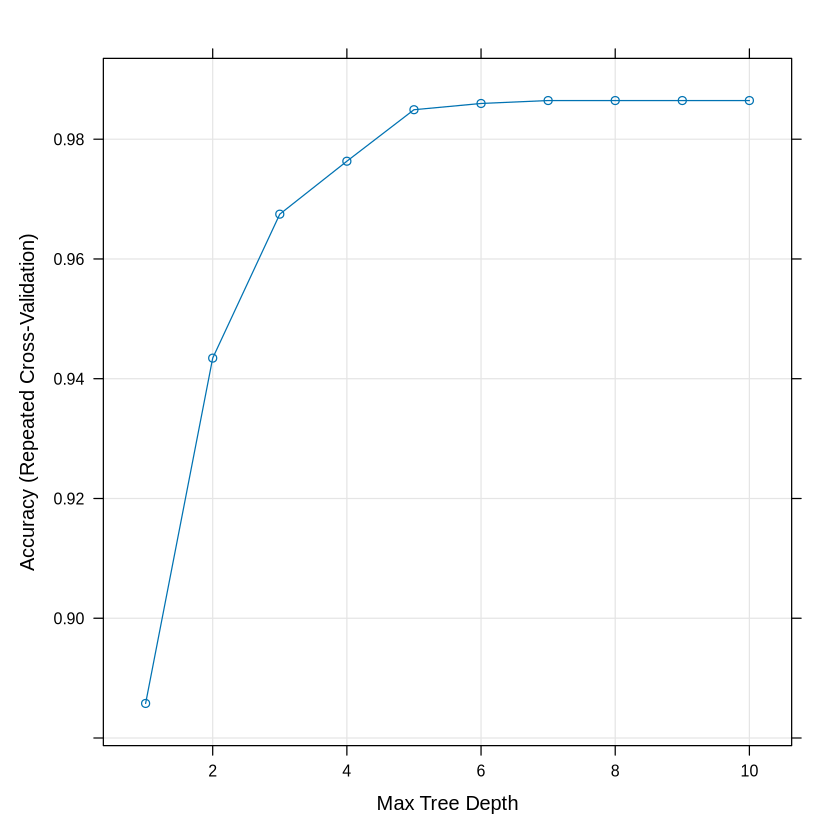

In [341]:
# Buscando el arbol óptimo aplicando una cross-validación con 3 folds y repitiendo 50 veces 
# para encontrar el óptimo

# Definir el control de entrenamiento con validación cruzada repetida
trctrl = trainControl(method = "repeatedcv", repeats = 50, number = 3)
# Entrenar el modelo con cross validation (trControl) y ajustando solo el profundidad de 1:10 para encontrar la óptima
tree_opt = train(class ~ ., dataset.train_msh,
              method = "rpart2",
              trControl = trctrl,                
              tuneGrid = expand.grid(maxdepth = 1:10))

plot(tree_opt)

En la gráfica podemos observar que el modelo alcanza su mayor precisión a una profundidad de 5. A partir de este punto, el valor de precisión se estabiliza, lo que sugiere que una mayor profundidad no mejora significativamente el rendimiento del modelo. Es importante observar que desde el tercer nivel alcanza un accuracy de aproximadamente 97%, lo cual es muy bueno. Accedamos a este modelo para ver el árbol, sus nodos terminales y las variables más relevantes.

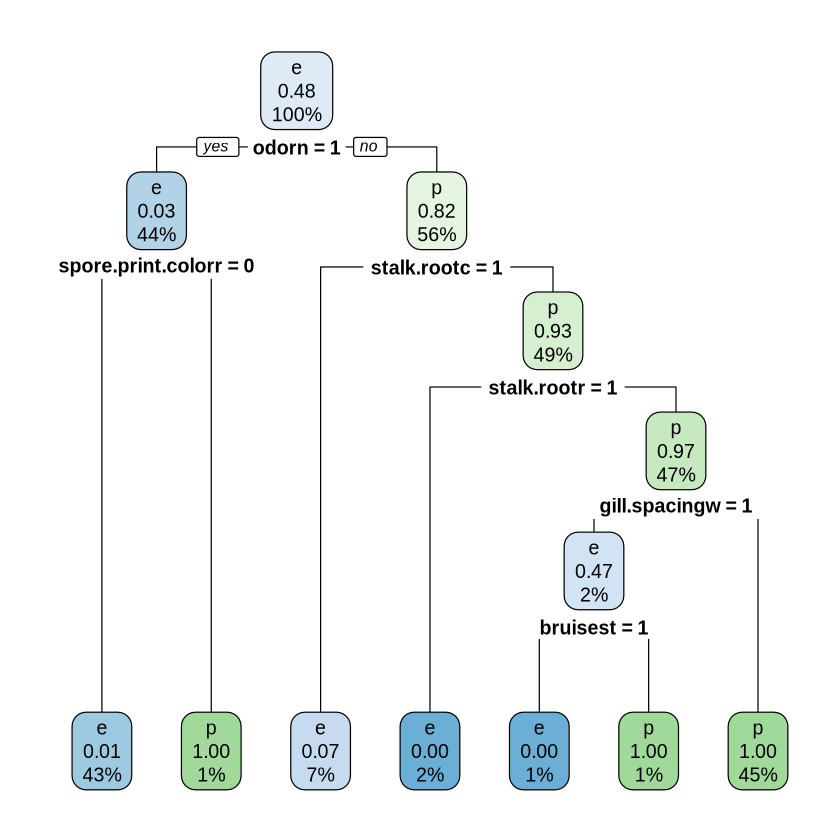

In [342]:
# Acceder al modelo final de árbol de decisión optimizado
tree_model_opt1 = tree_opt$finalModel

# Graficar el árbol de decisión
rpart.plot(tree_model_opt1)

Este arbol optimizado tiene 5 niveles de profundidad con 7 nodos terminales, donde alcanzan una pureza del 100% en casi todos, y los que no tienen un porcentaje bastente alto, lo cual es muy bueno para la lectura preliminar del modelo.

Respondiendo a la pregunta 1, si comparamos este modelo con el completo observamos que hay diferencias. En el arbol completo vemos que hay 7 niveles de profundidad y en el óptimo 5 niveles; observamos 7 terminales en el optimizado y 9 en el completo; y finalmente vemos cambios en las variables a considerar, como por ejemplo bruises y gill.spacing. Es importante mencionar que las variables de odor, spore.print.color y stalk.root permanecen. 

Por una parte, la diferencia de los niveles de profundidad se debe a la configuración del arbol completo, en donde se parametriza un crecimiento más amplio de sus ramas alcanzando 9 nodos terminales. Para el árbol óptimo no se estableció diferentes hyperparametros (como para el árbol completo cp = 0, minsplit = 2, minbucket = 1), solo se evaluó el maxdepth en un rango de 1:10, donde el modelo se detuvo a una profundidad de 5. El paquete de manera interna optimiza el modelo con un valor predeterminado de cp que no le permite llegar a esa profundidad y que da como resultado un modelo óptimo. 

Adicionalmente, en el modelo optimizado se observan variaciones en las reglas generadas por el árbol, debido a la sensibilidad inherente de los árboles de decisión frente a los datos de entrenamiento. Este fenómeno se debe a que el modelo es evaluado en múltiples subconjuntos (folds) durante la validación cruzada, lo que permite identificar patrones consistentes y mitigar el riesgo de sobreajuste. Al aplicar una validación cruzada con 3 folds y repetirla 50 veces, el modelo puede estabilizar mejor las reglas de división y destacar las variables más relevantes para la clasificación. Esto asegura que las divisiones no dependan de una única partición de los datos, genera un modelo más robusto y con mayor capacidad de generalización. 

Es importante concluir que este árbol optimizado muestra de igual manera que las variables odor y spore.print.color son las más significativas. 

Ahora bien, construyamos dos modelos más estableciendo la profundidad óptima de 5 para analizar los resultados de cómo se comporta la construcción de árboles de acuerdo a su configuración (profundidad), el uso de paquetes y cross validation.  

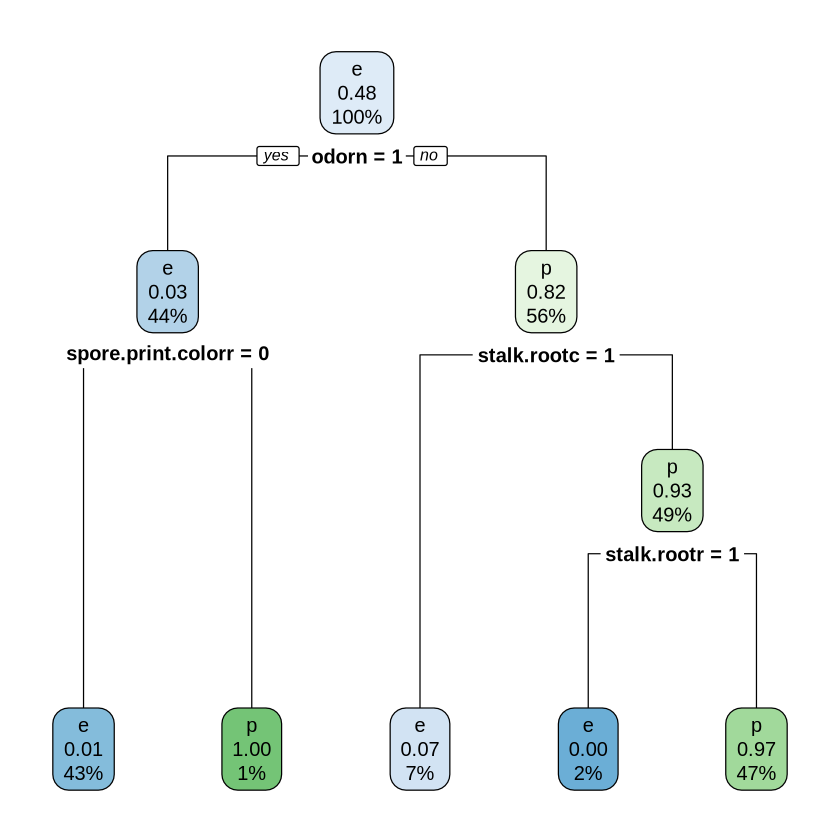

In [343]:
#modelo óptimo con caret parametrizando maxdepth = 5 (cross validation)
tree_opt2 = train(class ~ ., dataset.train_msh,
              method = "rpart2",
              trControl = trctrl,                
              maxdepth = 5)

# Acceder al modelo final de árbol de decisión optimizado
tree_model_opt2 = tree_opt2$finalModel

# Graficar el árbol de decisión
rpart.plot(tree_model_opt2)

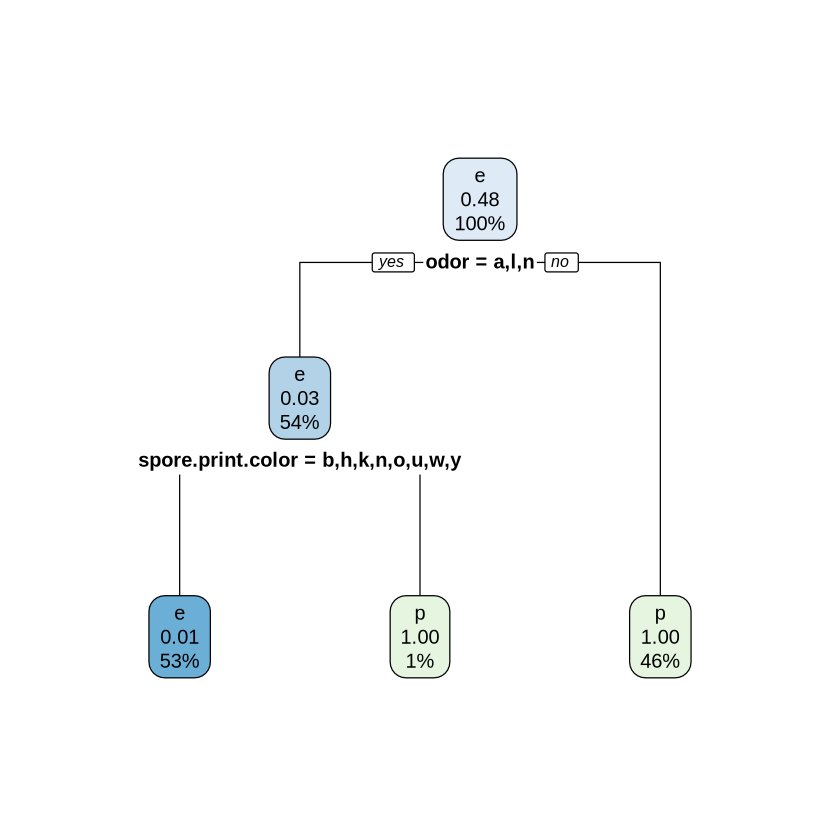

In [344]:
#modelo optimo con rpart parametrizando maxdepth = 5 (sin cross validation)
tree_model_opt3 = rpart(class ~ ., dataset.train_msh, 
               maxdepth = 5)
rpart.plot(tree_model_opt3)

Comparando los modelos óptimo 2 y 3, vemos que el número de niveles se redujo para el primer caso a 3 y el segundo a 2, coincidiendo en las variables de odor y spor.print.color como las principales (al igual que el completo y el óptimo 1). Además, vemos que los nodos terminales son 5 y 3 respectivamente, con valores altos en la pureza de los datos de cada uno de los nodos para ambos casos. 

Por otra parte, pese al parámetro de profundidad de 5, se obtuvieron resultados diferentes en ambos árboles. Es importante destacar que este comportamiento se debe a que cada paquete tiene diferentes tipos y formas en las que evalúa los hyper-parametros, por lo cual los resultados no son el mismo. Adicionalmente, se puede analizar que es coherente que los modelos optimizados 2 y 3 presenten un nivel de profundidad inferior al parametrizado debido a que en la gráfica de Acurracy y profundidad, vemos que a un nivel 3 se alcanza un porcentaje mayor al 96%. Esto quiere decir que estos paquetes están evaluando otros hyper-parámetros previos para optimizar el modelo (como podría ser el cp), no permitiéndole llegar a la profundidad establecida.

Finalmente, vemos que con cross validation obtenemos un árbol más profundo (modelo optimo 2 con respecto al 3) que abarca otra variable adicional. Esto ultimo va de la mano con lo mencionado anteriormente frente a la sensibilidad de los árboles, donde cross validation nos ayuda a tener un arbol más estable. 

Ahora bien, revisemos el accuracy de los 3 modelos optimizados frente a su desempeño en la predicción.

In [365]:
#Revisamos el accuracy de los modelos
# Predicción - test
Pred.tree.te_c = predict(tree_completo, dataset.test_msh, type = "class")
Pred.tree.te_opt1 = predict(tree_opt, dataset.test_msh, type = "raw")
Pred.tree.te_opt2 = predict(tree_opt2, dataset.test_msh, type = "raw") 
Pred.tree.te_opt3 = predict(tree_model_opt3, dataset.test_msh, type = "class")

In [366]:
#Validación de prediccion en función de accuracy
#Accuracy Test
acc.te_comp = acc.class(Pred.tree.te_c, dataset.test_msh$class)
acc.te_opt1 = acc.class(Pred.tree.te_opt1, dataset.test_msh$class)
acc.te_opt2 = acc.class(Pred.tree.te_opt2, dataset.test_msh$class)
acc.te_opt3 = acc.class(Pred.tree.te_opt3, dataset.test_msh$class)

#resultados
cat("Arbol completo:", acc.te_comp, "\n")
cat("Arbol opt1 (cross validation - 5 niveles):", acc.te_opt1, "\n")
cat("Arbol opt2 (cross validation - 3 niveles):", acc.te_opt2, "\n")
cat("Arbol opt3 (sin cross validation - 2 niveles):", acc.te_opt3, "\n") 

Arbol completo: 1 
Arbol opt1 (cross validation - 5 niveles): 0.990645 
Arbol opt2 (cross validation - 3 niveles): 0.9822747 
Arbol opt3 (sin cross validation - 2 niveles): 0.9945839 




Los modelos optimizados son suficientes para predecir la variable objetivo, debido a que todos presentan un valor alto de accuracy con los datos de te (modelos capaz de generalizar)st. El modelo optimizado 3 con pocas divisiones y variables llega a una clasificación correcta (2 niveles, 2 variables), y no es un modelo complejo. Por otro lado, el modelo optimizado 2 de igual manera es un modelo simple con 3 niveles de profundidad, siendo capaz de clasificar correctamente, pero con el respaldo de la cross validation, la cual garantiza la estabilidad del modelo. El modelo 1 tiene el respaldo de cross validation pero es un modelo más complejo (más variables), y los resultados con respecto al modelo 2 no son significativo

Es importante observar que el árbol completo alcanza una clasificación perfecta (100% de accuracy), lo cual indica que es un modelo altamente complejo que se ajusta a los datos. Sin embargo, este resultado puede no ser favorable, ya que suele ser una señal de sobreajuste. Esto significa que el modelo se ajusta excesivamente a los datos, pero podría fallar al generalizar ante nuevos datos que no conoce.



Con estos resultados podemos concluir que para este problema es posible construir un modelo sencillo con pocas variables (2 principalmente) que logre predecir adecuadamente la clasificación de hongos venenoso y comestible. Respondiendo a la pregunta 2, las variables de mayor peso a la hora de clasificar son odor y spore.print.color debido a que en los 3 modelos observados fueron las variables que permanecieron en los primeros niveles a la hora de clasifica. 

Vamos a construir un modelo con las dos variables que mayor peso tienen a la hora de clasificar, que son odor y sporte.print.color para analizar sus resultados.

Arbol 2 variables (sin cross validation): 0.9945839 
error test:  0.005416051

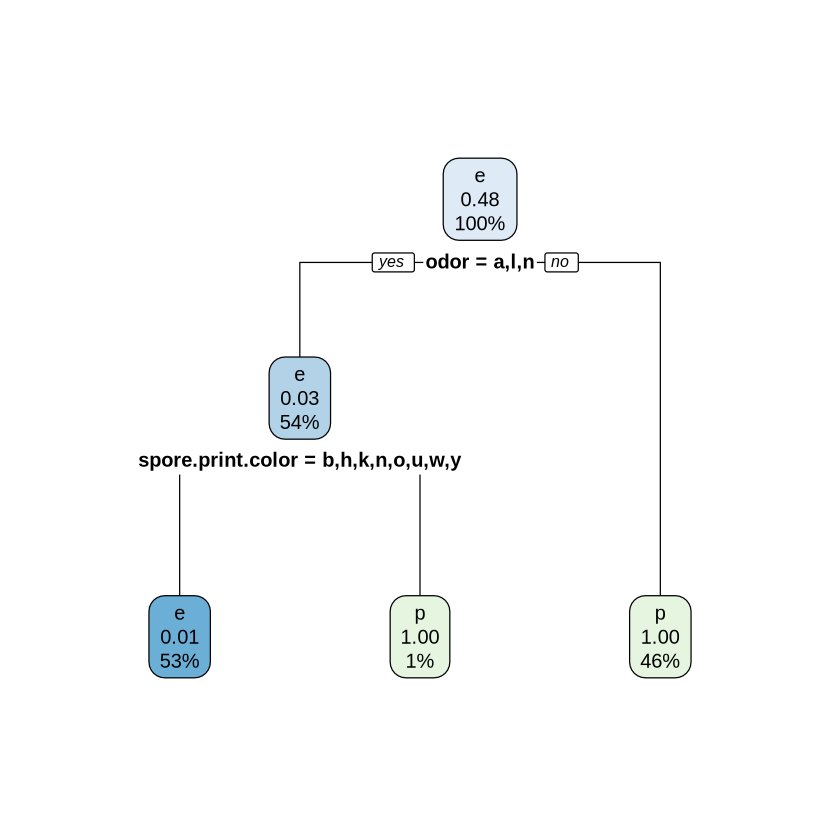

In [356]:
# Pregunta 2: ¿Cuáles son las dos variables que mayor peso tienen a la hora de clasificar? Entrena un nuevo árbol considerando como predictores únicamente esas dos variables. ¿Qué resultados obtienes? 
#Las variables que mayor peso tienen a la hora de clasificar son odor y spore.print.color lo cual se puede evidenciar con el analisis del punto anterior.

#Nuevo modelo con las dos variables de mayor peso
tree_2var = rpart(class ~ odor + spore.print.color, dataset.train_msh)
rpart.plot(tree_2var)
#predicción 
Pred_tree_2var = predict(tree_2var, dataset.test_msh, type = "class")
acc_2var = acc.class(Pred_tree_2var, dataset.test_msh$class)

cat("Arbol 2 variables (sin cross validation):", acc_2var, "\n")
cat("error test: ", (1-acc_2var))

Arbol 2 variables (cross validation): 0.9414082 
error test:  0.05859183

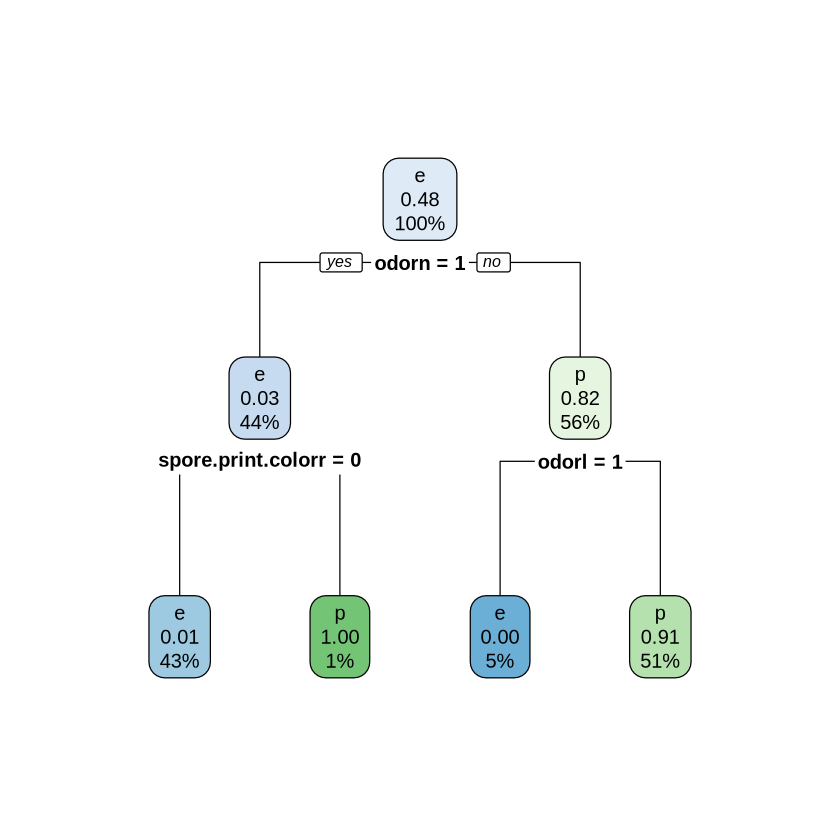

In [357]:
#Nuevo modelo con las dos variables de mayor peso aplicando cross validation
tree_2var_cv = train(class ~ odor + spore.print.color, dataset.train_msh, method = "rpart2", trControl = trctrl)
rpart.plot(tree_2var_cv$finalModel)

Pred_tree_2var_cv = predict(tree_2var_cv, dataset.test_msh)
acc_2var_cv = acc.class(Pred_tree_2var_cv, dataset.test_msh$class)

cat("Arbol 2 variables (cross validation):", acc_2var_cv, "\n")
cat("error test: ", (1-acc_2var_cv))

Analizando la pregunta 2, los resultados muestran que tanto el modelo generado sin validación cruzada (usando rpart) como el que incluye validación cruzada (usando caret) logran clasificar correctamente basándose únicamente en las dos variables principales identificadas: odor y spore.print.color. El modelo de rpart alcanza un accuracy del 99% (error de test de aproximadamente 1%), mientras que el modelo de caret con validación cruzada obtiene un accuracy del 94% (error de test de aproximadamente 6%). Aunque el modelo de rpart parece más preciso, la diferencia no es significativa en este caso. Sin embargo, la validación cruzada respalda al modelo generado con caret, haciéndolo más robusto y estable frente a variaciones en los datos.

Ahora vamos a construir dos modelos considerando otras variables diferentes a las identificadas como las mas importantes, uno utilizando variables que se destacan en el arbol completo y otro variables que no aparecen en este, ambos modelos sin validación cruzada. Es importante mencionar que, durante la validación cruzada, el modelo se evalúa en múltiples subconjuntos (folds) de los datos. Es probable que algunas particiones sean más difíciles de predecir que otras, lo que puede bajar ligeramente el promedio de accuracy comparado con la evaluación en un único conjunto de prueba.

Arbol 2 variables diferentes (variables de tree completo): 0.8537666 
error test:  0.1462334

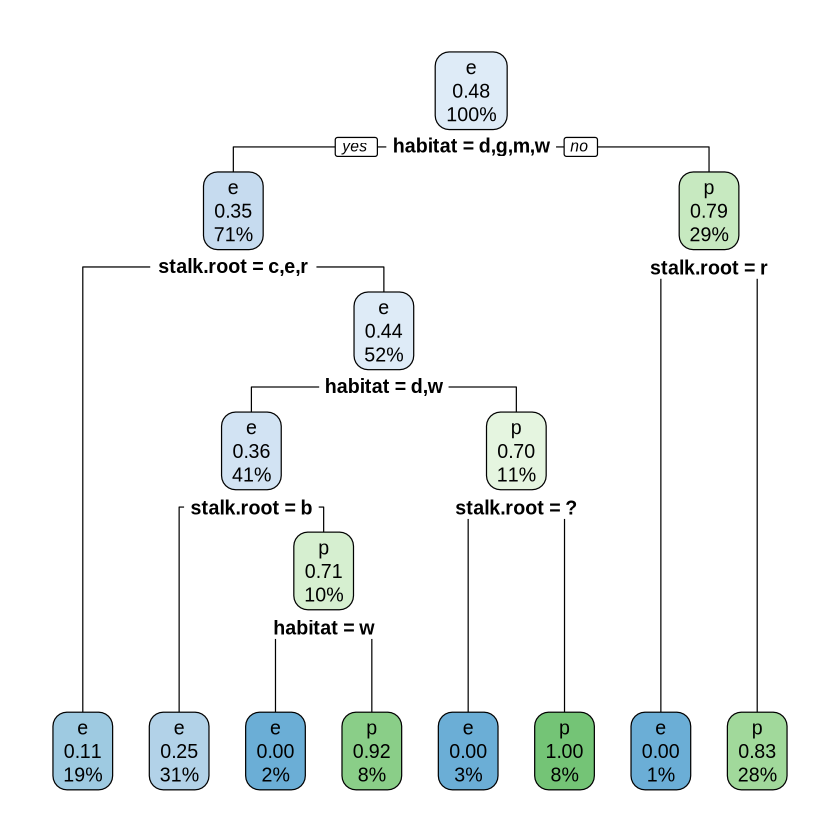

In [352]:
# Pregunta 3 :Entrena un nuevo árbol considerando como predictores cualesquiera otras dos variables que no sean las utilizadas en la pregunta anterior. ¿Cuál es el error de test de este árbol?

#Nuevo modelo con las dos variables diferentes que estan en tree completo
tree_n = rpart(class ~ habitat + stalk.root, dataset.train_msh)
rpart.plot(tree_n)

#predicción 
Pred_tree_n = predict(tree_n, dataset.test_msh, type = "class")
acc_n = acc.class(Pred_tree_n, dataset.test_msh$class)

cat("Arbol 2 variables diferentes (variables de tree completo):", acc_n, "\n")
cat("error test: ", (1-acc_n))

Arbol 2 variables diferentes (variables que no aparecen en tree completo): 0.7572624 
error test:  0.2427376

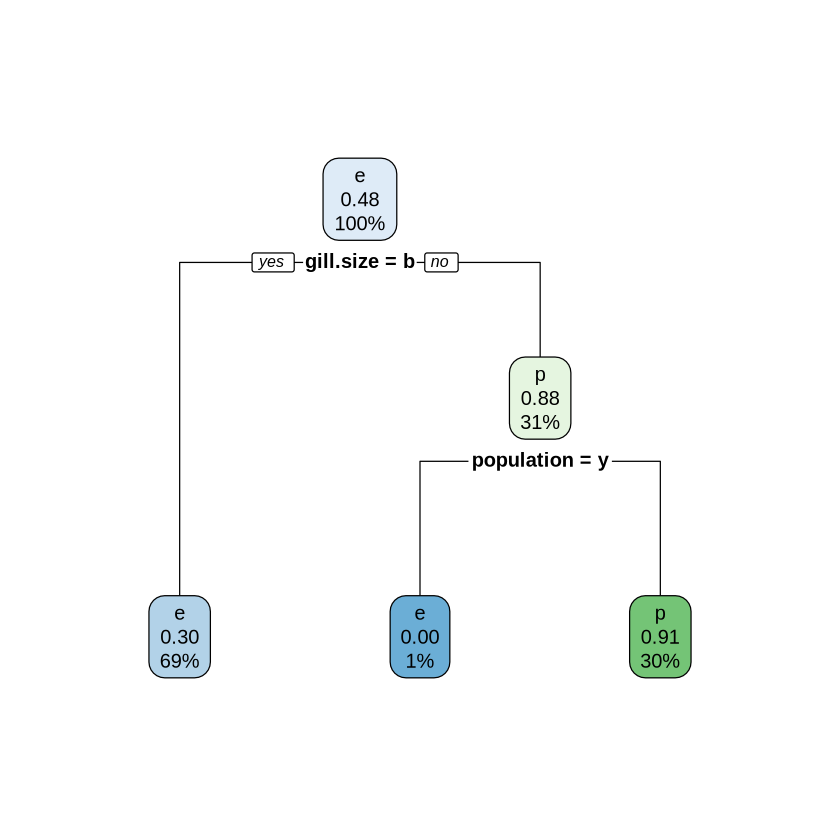

In [355]:
#utilizando variables que no aparecen en el modelo completo
#identificando variables
#str(dataset_mushroom)

tree_n2 = rpart(class ~ gill.size + population, dataset.train_msh)
rpart.plot(tree_n2)

#predicción 
Pred_tree_n2 = predict(tree_n2, dataset.test_msh, type = "class")
acc_n2 = acc.class(Pred_tree_n2, dataset.test_msh$class)

cat("Arbol 2 variables diferentes (variables que no aparecen en tree completo):", acc_n2, "\n")
cat("error test: ", (1-acc_n2))

Respondiendo a la pregunta 3, pese a que se construyeron modelos sin cross validation, se observa que ambos modelos arrojaron un accuracy inferior a los identificados en el punto anterior, obteniendo un error de test de aproximadamente 15% para el modelo creado con habitat + stalk.root y 25% para el modelo creado con gill.size + population. Sin embargo, observamos que estos resultados no son tan malos, especialmente los obtenidos por el modelo de habitat + stalk.root. Esto quiere decir que otras variables diferentes a las identificadas en el modelo como principales son capaces de predecir la variable objetivo de que si un hongo es venenoso o comestible, pero con niveles más altos de error. Teniendo en cuenta que quizas podria ser una clasificación que represente la vida, muerte y/o enfermedad de una persona, es mejor considerar el modelo optimizado con cross validation considerando las variables odor y spore.print.color, para garantizar un test de error mucho menor. 

### Punto 3 (3 puntos):

Por un lado, las ramas del árbol pueden ser interpretadas como reglas de forma similar a las obtenidas por el algoritmo de reglas aplicado. Por ejemplo, en el caso del árbol obtenido con el dataset `Play Tennis` puede obtenerse las siguientes `reglas`: SI Outlook = Overcast -> Play Tennis = Yes ó SI (Outlook = Sunny) AND (Humidity = Normal) -> Play Tennis = Yes, cuya confianza asociada viene dada por la frecuencia relativa de cada caso en esa rama del árbol. Por otro lado, considerando las reglas que implican a nuestra variable objetivo tendríamos un `modelo` similar al dado por el árbol. Considerar y comparar ambas aproximaciones (p.e. ¿coinciden los antecedentes de las reglas? ¿alguna de las variables más frecuentes como antecedente en las reglas se corresponde con alguna de las variables con mayor capacidad de discriminación? etc.). 

Warning message:
“Too many rules supplied. Only plotting the best 100 using ‘lift’ (change control parameter max if needed).”


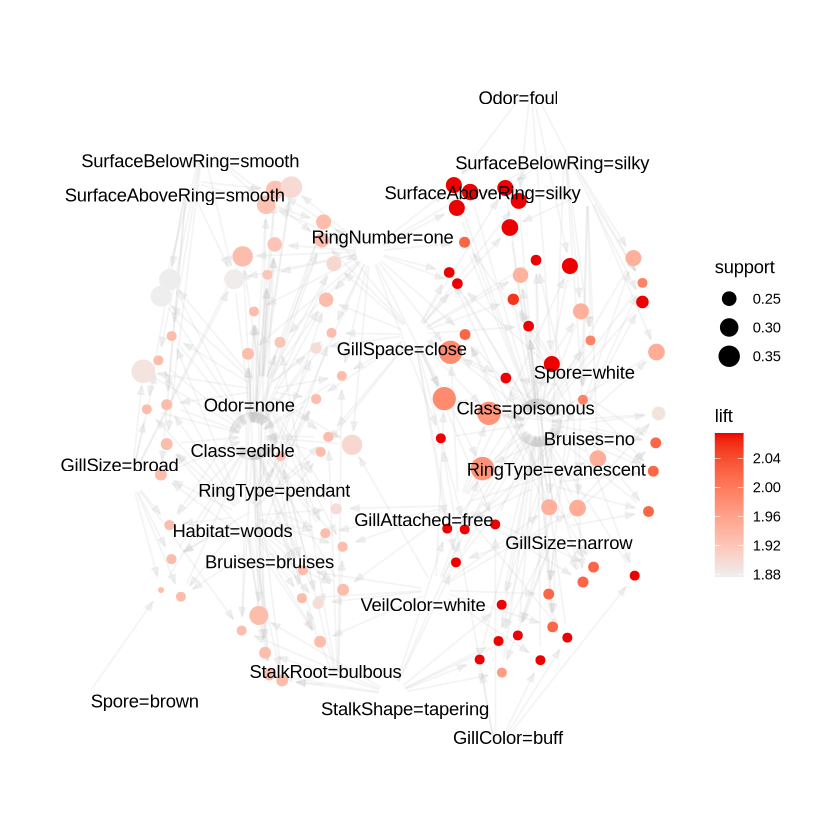

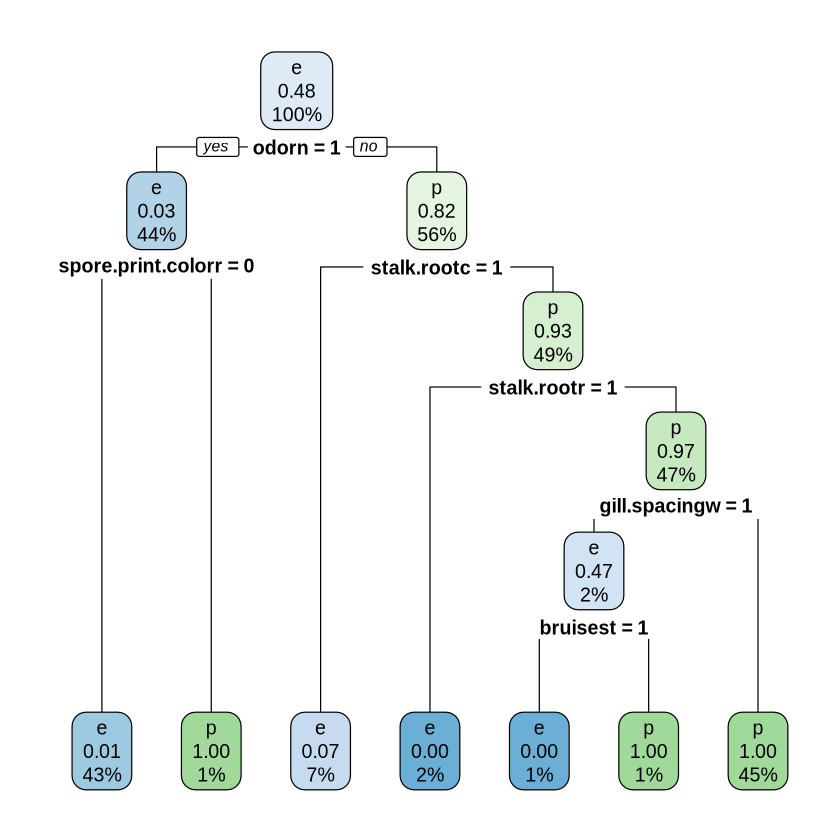

In [327]:
# Grafico de reglas para Class=edible y Class=poisonous 
plot(subset_rhs, method = "graph")

# Graficar el árbol de decisión modelo optimo 1
rpart.plot(tree_model_opt1)

Considerando la última gráfica del primer punto y el arbol optimizado 1 del punto 2, tenemos que hay coincidencias de los nodos del arbol con algunos items de reglas generadas, como es el caso de las variables odor, stalkroot, gillspace y bruises. En el caso de odor, vemos que en la gráfica de reglas de asociación tanto para las reglas de variable consecuente de edible como poisonuos, esta caracteristica en los hongos es importante para la clasificación o su explicación. En el gráfico de reglas se observan los items odor=none y odor=foul, y en el arbol se observa que la variable más importante de clasificación es odorn (que es igual a odor=none), por la cual hace su primer split. 

De igual forma, vemos en la gráfica que el item gillSpace=close se destaca por coincidir en los itemsets que se relacionan con los consecuentes class=edible y class=poisonuos, y vemos que es la variable del nivel 4 del arbol. La variable bruises es importante para definir la clasificación en el arbol y se encuentran en las reglas como bruises=bruises y bruises=no. Finalmente, la variable stalk.root es importante para identificar la clase edible tanto en el arbol como en las reglas.  

Es importante destacar que en el gráfico de reglas de asociación aparecen muchos otros items que no estan en el arbol optimizado, lo cual es normal debido a que las eglas de asociación analizan todas las combinaciones para identificar patrones y los arboles son una estructura jerárquica que permite tomar decisiones con base en divisiones (nodos) que se optimizan a travás de unos parámetros. Además, es posible observar su relación debido a que cada split de en un arbol esta compuesto por reglas que permiten ir clasificando la variable objetivo. Al final de cada nodo terminar, tenemos una suma de reglas que permiten predecir la variable.